# 01 — Data survey: La Liga 2015/16

Establishes what we are modelling before we model it. Three questions:

1. **Which competition-season?** The free StatsBomb tier is uneven, and the wrong choice bakes in bias that no model can undo.
2. **Is the data trustworthy?** Real data has real defects; the ones here need to be known, not discovered at training time.
3. **What does the signal look like?** Where shots come from, how often they score, and which of that is worth turning into a feature.

Data provided by **StatsBomb** via [Open Data](https://github.com/statsbomb/open-data).

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mplsoccer import Pitch, VerticalPitch

from football_xg import config, data, validate

config.ensure_dirs()
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110

SAVE = config.FIGURES_DIR
print("figures ->", SAVE)

figures -> /Users/yoosufahamed/Desktop/Projects/ML xG Football Goals & Prediction/Football-xG-Match-Outcome-Prediction/reports/figures


## 1. Choosing the competition-season

StatsBomb's free tier has a trap in it. Most La Liga seasons in the release are *Barcelona-only* — every match in the season features one club, because the data was published to showcase Messi's career. An xG model trained on that learns one team's shot profile and calls it football.

The check below is the reason `config.COMPETITION_ID` is what it is. For each candidate: how many matches, how many distinct teams, and — the decisive column — what share of matches the single most-covered team appears in. **10% means a balanced league; 100% means a single-team highlight reel.**

In [ ]:
from collections import Counter

CANDIDATES = [
    (11, 27, "La Liga 2015/16"),
    (11, 90, "La Liga 2020/21"),
    (2, 27, "Premier League 2015/16"),
    (9, 281, "Bundesliga 2023/24"),
    (7, 235, "Ligue 1 2022/23"),
    (43, 106, "World Cup 2022"),
    (55, 282, "Euro 2024"),
]

rows = []
for cid, sid, label in CANDIDATES:
    m = data.load_matches(cid, sid)
    appearances = Counter(m["home_team"]) + Counter(m["away_team"])
    top_team, top_n = appearances.most_common(1)[0]
    rows.append({
        "competition": label,
        "matches": len(m),
        "teams": len(appearances),
        "most covered team": top_team,
        "their share of matches": top_n / len(m),
    })

survey = pd.DataFrame(rows).sort_values("matches", ascending=False)
survey.style.format({"their share of matches": "{:.0%}"}).background_gradient(
    subset=["their share of matches"], cmap="Reds"
)

,competition,matches,teams,most covered team,their share of matches
0,La Liga 2015/16,380,20,Málaga,10%
2,Premier League 2015/16,380,20,Chelsea,10%
5,World Cup 2022,64,32,Argentina,11%
6,Euro 2024,51,24,Spain,14%
1,La Liga 2020/21,35,19,Barcelona,100%
3,Bundesliga 2023/24,34,18,Bayer Leverkusen,100%
4,Ligue 1 2022/23,32,20,Paris Saint-Germain,100%


**La Liga 2015/16 is the pick**: the complete 380-match season, all 20 teams, and no team in more than ~10% of matches. It is one of the few full-league releases in the free tier, and it happens to be exactly the example the project brief suggested.

The Barcelona-only seasons are visible above at 100% — as is the Bundesliga 2023/24 release (Leverkusen-only) and Ligue 1 2022/23 (PSG-only). The tournaments are balanced but small: 64 and 51 matches against La Liga's 380.

In [ ]:
matches = data.load_matches()
events = data.load_season_events()
shots = data.build_shots_table(events, matches)

print(f"{config.COMPETITION_LABEL}")
print(f"  matches : {len(matches)}")
print(f"  events  : {len(events):,}")
print(f"  shots   : {len(shots):,}")
print(f"  window  : {matches['match_date'].min():%Y-%m-%d} -> {matches['match_date'].max():%Y-%m-%d}")

La Liga 2015/2016
  matches : 380
  events  : 1,295,354
  shots   : 9,168
  window  : 2015-08-21 -> 2016-05-15


## 2. Does the data hold up?

Every check the pipeline knows how to run. These are assertions about reality, not unit tests — they run against the real season and report rather than raise, because most findings are things to *handle* downstream, not reasons to stop.

In [ ]:
findings = validate.run_all_checks(matches, shots, events)

[WARN] missing: 81 shots (0.88%) have no freeze frame; defensive features cannot be computed for these
[NOTE] locations: 11 shots (0.12%) from the defensive half
[OK  ] leakage: no post-shot fields in the shots table
[OK  ] duplicates: all 9168 shot ids unique
[OK  ] match_ids: every shot maps to a known match
[OK  ] team_ids: every shot's team plays in its own fixture
[OK  ] locations: all shots inside the pitch
[OK  ] missing: no gaps in required shot fields
[OK  ] class_balance: 1014 goals in 9168 shots (11.06%); a model predicting 'no goal' always would score 88.94% accuracy
[OK  ] scores: all 1043 goals in 380 matches reconcile with shots + 29 own goals, exactly

10 checks, none failing


Three of these deserve comment.

**The score reconciliation is the strongest check here.** It ties our derived tables back to an independent field — the recorded scoreline — that nothing in our pipeline touches. Shot-goals alone don't reconcile, because an own goal is its own event type rather than a shot. Adding own goals closes the gap to *exactly zero* across all 380 matches, which is good evidence no shots are being lost or double-counted.

**81 shots (0.9%) have no freeze frame.** The freeze frame is the snapshot of every player's position at the moment of the shot — it's what makes "defenders in the shot cone" computable. Nearly 1% of shots can't have those features, so the feature layer needs a defined answer for them rather than a silent NaN.

**11 shots come from the defensive half.** Long-range efforts, not a coordinate bug — if the attacking-direction normalisation were broken we'd see roughly half the shots there.

## 3. Class balance

The single most important number for how this model gets evaluated.

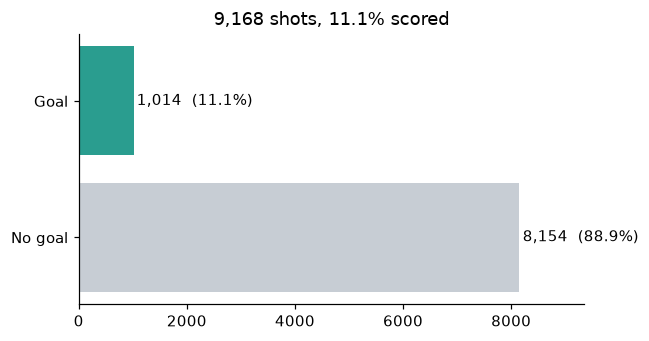

Always predicting 'no goal' scores 88.94% accuracy while being useless.
This is why the project is scored on log loss, Brier score and calibration.


In [ ]:
goals = int(shots["is_goal"].sum())
rate = shots["is_goal"].mean()

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.barh(["No goal", "Goal"], [len(shots) - goals, goals], color=["#c7cdd4", "#2a9d8f"])
for i, v in enumerate([len(shots) - goals, goals]):
    ax.text(v + 60, i, f"{v:,}  ({v/len(shots):.1%})", va="center", fontsize=10)
ax.set_xlim(0, len(shots) * 1.02)
ax.set_title(f"{len(shots):,} shots, {rate:.1%} scored")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(SAVE / "class_balance.png", bbox_inches="tight")
plt.show()

print(f"Always predicting 'no goal' scores {1 - rate:.2%} accuracy while being useless.")
print("This is why the project is scored on log loss, Brier score and calibration.")

Roughly one shot in nine is a goal. **Accuracy is not a usable metric here** — a model that predicts "no goal" for every shot is 88.9% accurate and has learned nothing. What an xG model is actually for is producing *honest probabilities*: when it says 0.3, roughly 30% of those shots should go in. That is what log loss, Brier score and calibration curves measure, and it's why they're the metrics in the brief.

## 4. Where shots come from, and which ones score

The shot map plots every shot in the season. Goals are drawn on top and sized by StatsBomb's xG.

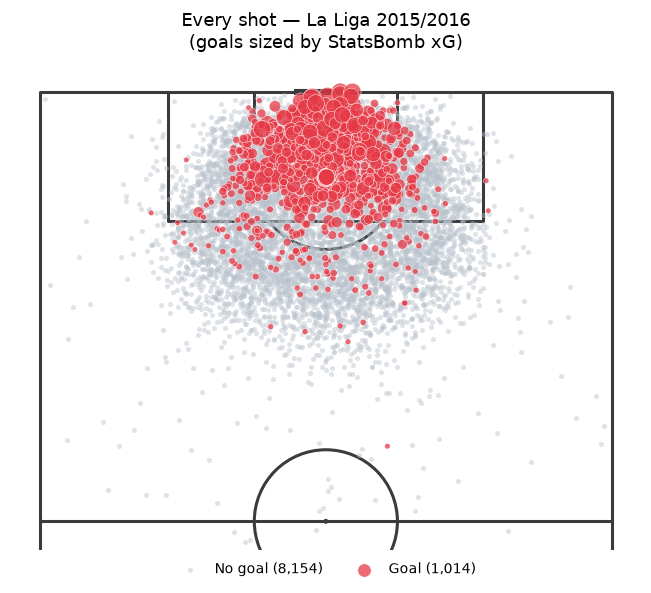

In [ ]:
pitch = VerticalPitch(pitch_type="statsbomb", half=True, line_color="#3b3b3b", pitch_color="white")
fig, ax = pitch.draw(figsize=(8, 5.5))

misses = shots[shots["is_goal"] == 0]
scored = shots[shots["is_goal"] == 1]

pitch.scatter(misses["x"], misses["y"], ax=ax, s=11, color="#b9c2cc", alpha=0.45, linewidth=0, label=f"No goal ({len(misses):,})")
pitch.scatter(scored["x"], scored["y"], ax=ax, s=scored["shot_statsbomb_xg"] * 130 + 12,
              color="#e63946", alpha=0.75, edgecolors="white", linewidth=0.4, label=f"Goal ({len(scored):,})")

ax.legend(loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.08), fontsize=9)
ax.set_title(f"Every shot — {config.COMPETITION_LABEL}\n(goals sized by StatsBomb xG)", pad=10, fontsize=12)
fig.savefig(SAVE / "shot_map.png", bbox_inches="tight")
plt.show()

The goals collapse into the six-yard box and the penalty spot while misses spray across the whole final third. That concentration *is* the signal an xG model exists to capture — and it says location will dominate any feature set.

## 5. Shot volume vs. conversion by zone

Volume and conversion are different maps, and the difference between them is the interesting part.

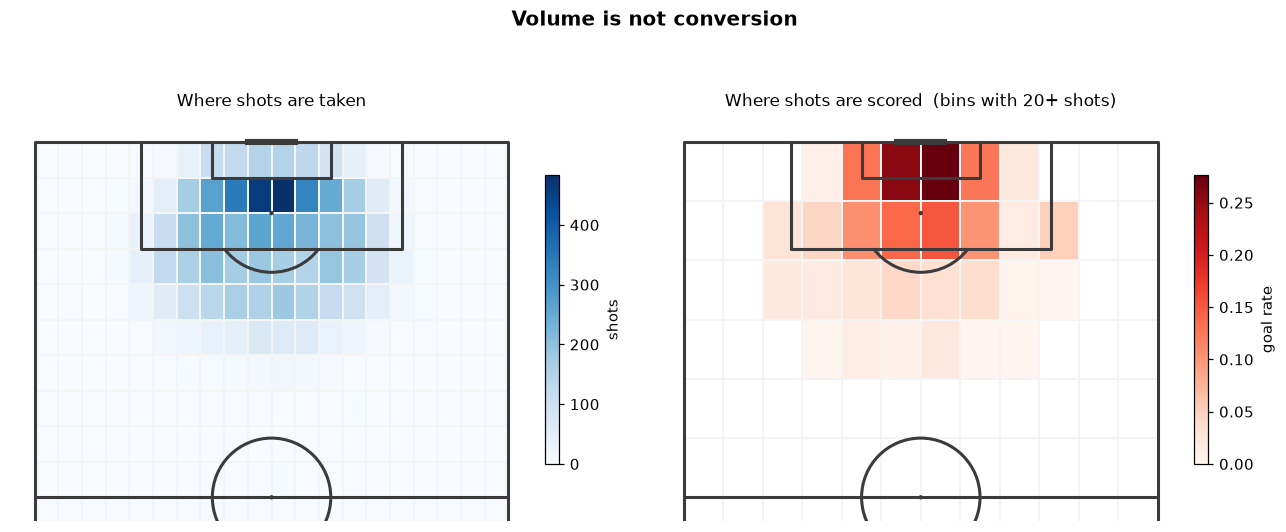

peak conversion in any bin: 28%  (base rate 10.4%)


In [ ]:
# line_zorder=2 draws the pitch markings *over* the heatmap; without it the
# mesh covers the six-yard box and the plot loses its frame of reference.
pitch = VerticalPitch(pitch_type="statsbomb", half=True, line_color="#3b3b3b",
                      pitch_color="white", line_zorder=2)

# Penalties would put a false hotspot on the spot in the conversion map, so the
# geography of open play is read without them.
op = shots[~shots["is_penalty"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))

# Volume: where do players shoot from?
pitch.draw(ax=axes[0])
bs = pitch.bin_statistic(op["x"], op["y"], statistic="count", bins=(20, 20))
hm0 = pitch.heatmap(bs, ax=axes[0], cmap="Blues", edgecolor="#f4f4f4", linewidth=0.1)
fig.colorbar(hm0, ax=axes[0], shrink=0.55, pad=0.02, label="shots")
axes[0].set_title("Where shots are taken", pad=8, fontsize=11)

# Conversion: where do they go in?  Sparse bins are noise, so require 20+.
bs_goal = pitch.bin_statistic(op["x"], op["y"], values=op["is_goal"], statistic="mean", bins=(12, 12))
bs_count = pitch.bin_statistic(op["x"], op["y"], statistic="count", bins=(12, 12))
bs_goal["statistic"] = np.where(bs_count["statistic"] >= 20, bs_goal["statistic"], np.nan)

pitch.draw(ax=axes[1])
hm1 = pitch.heatmap(bs_goal, ax=axes[1], cmap="Reds", edgecolor="#f4f4f4", linewidth=0.1,
                    vmin=0, vmax=np.nanmax(bs_goal["statistic"]))
fig.colorbar(hm1, ax=axes[1], shrink=0.55, pad=0.02, label="goal rate")
axes[1].set_title("Where shots are scored  (bins with 20+ shots)", pad=8, fontsize=11)

fig.suptitle("Volume is not conversion", y=0.99, fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(SAVE / "volume_vs_conversion.png", bbox_inches="tight")
plt.show()

peak = np.nanmax(bs_goal["statistic"])
print(f"peak conversion in any bin: {peak:.0%}  (base rate {op['is_goal'].mean():.1%})")

These two maps are the project in one picture. Volume peaks **around the penalty spot** — the modal open-play shot comes from 10–12 yards, and the distribution trails off gradually past 30. Conversion peaks in a much tighter region, **inside the six-yard box**, and has already collapsed by the penalty spot where the volume peak sits.

The maps disagreeing is the entire premise of xG: *shot count is a bad proxy for chance quality*, because the places players shoot from most are not the places they score from most. A team that takes 20 speculative efforts from the D has not outplayed a team that took 4 from the six-yard box — and that's precisely what a raw shot count would tell you.

## 6. The two features that will carry the model

Distance and angle to goal. Neither exists in the data yet — both are derived from the shot's coordinates and the goal geometry in `config`. This is a preview of step 3, computed inline to check the signal is really there.

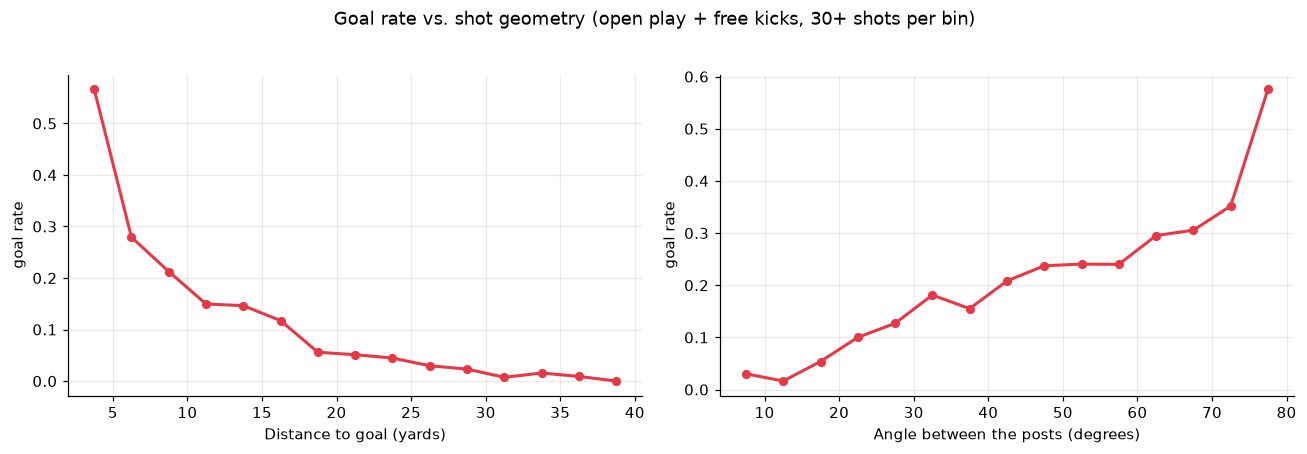

In [ ]:
# Distance to the centre of the goal, and the angle subtended by the two posts.
# A shot on the goal line wide of the post has ~0 angle; a shot on the spot has a wide one.
gx, gy = config.GOAL_CENTER
dx = gx - shots["x"]
dy = gy - shots["y"]
distance = np.sqrt(dx**2 + dy**2)

post_l = np.array(config.GOAL_POST_LEFT)
post_r = np.array(config.GOAL_POST_RIGHT)
v_l = post_l - shots[["x", "y"]].to_numpy()
v_r = post_r - shots[["x", "y"]].to_numpy()
cos = (v_l * v_r).sum(1) / (np.linalg.norm(v_l, axis=1) * np.linalg.norm(v_r, axis=1))
angle = np.degrees(np.arccos(np.clip(cos, -1, 1)))

preview = shots.assign(distance=distance, angle=angle)
open_play = preview[~preview["is_penalty"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label, edges in [
    (axes[0], "distance", "Distance to goal (yards)", np.arange(0, 45, 2.5)),
    (axes[1], "angle", "Angle between the posts (degrees)", np.arange(0, 95, 5)),
]:
    binned = pd.cut(open_play[col], edges)
    g = open_play.groupby(binned, observed=True).agg(rate=("is_goal", "mean"), n=("is_goal", "size"))
    g = g[g["n"] >= 30]
    centres = [i.mid for i in g.index]
    ax.plot(centres, g["rate"], "o-", color="#e63946", linewidth=2, markersize=5)
    ax.set_xlabel(label)
    ax.set_ylabel("goal rate")
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Goal rate vs. shot geometry (open play + free kicks, 30+ shots per bin)", y=1.02)
fig.tight_layout()
fig.savefig(SAVE / "distance_angle_signal.png", bbox_inches="tight")
plt.show()

Both are strong, monotonic and non-linear — exactly what a gradient-boosted model eats for breakfast. Conversion falls off a cliff in the first ~12 yards and flattens into a long tail, and rises steeply once the angle opens past ~30°. Neither relationship is linear, which is an argument against plain logistic regression as the baseline.

## 7. What else moves conversion

Categorical context, ranked by how far each level departs from the ~11% base rate.

In [ ]:
def conversion_by(col, frame=shots, min_n=30):
    g = frame.groupby(col, observed=True).agg(shots=("is_goal", "size"), goals=("is_goal", "sum"))
    g["rate"] = g["goals"] / g["shots"]
    return g[g["shots"] >= min_n].sort_values("rate", ascending=False)

for col in ["shot_type", "shot_body_part", "shot_technique", "play_pattern"]:
    print(f"--- {col} ---")
    print(conversion_by(col).to_string(formatters={"rate": "{:.1%}".format}))
    print()

--- shot_type ---
           shots  goals  rate
shot_type                    
Penalty       97     69 71.1%
Open Play   8661    916 10.6%
Free Kick    409     29  7.1%

--- shot_body_part ---
                shots  goals  rate
shot_body_part                    
Right Foot       4682    533 11.4%
Head             1495    170 11.4%
Left Foot        2973    306 10.3%

--- shot_technique ---
                shots  goals  rate
shot_technique                    
Lob               125     30 24.0%
Overhead Kick      62      9 14.5%
Volley            633     86 13.6%
Diving Header      40      5 12.5%
Backheel           41      5 12.2%
Normal           6784    729 10.7%
Half Volley      1483    150 10.1%

--- play_pattern ---
                shots  goals  rate
play_pattern                      
Other             109     73 67.0%
From Counter      400     73 18.2%
From Goal Kick    319     37 11.6%
Regular Play     3062    339 11.1%
From Free Kick   1913    193 10.1%
From Keeper       134     1

`play_pattern = "Other"` converting at **67%** against a ~11% base rate is not a discovery, it's a trap. Worth chasing down rather than encoding.

In [ ]:
print(pd.crosstab(shots["play_pattern"], shots["shot_type"]).to_string())
other = shots[shots["play_pattern"] == "Other"]
print(f"\n'Other' is {len(other)} shots, of which {other['is_penalty'].sum()} are penalties.")

shot_type       Corner  Free Kick  Open Play  Penalty
play_pattern                                         
From Corner          1          0       1526        0
From Counter         0          0        400        0
From Free Kick       0        409       1504        0
From Goal Kick       0          0        319        0
From Keeper          0          0        134        0
From Kick Off        0          0         99        0
From Throw In        0          0       1605        0
Other                0          0         12       97
Regular Play         0          0       3062        0

'Other' is 109 shots, of which 97 are penalties.


There it is: **97 of the 109 "Other" shots are penalties.** The 67% conversion is the penalty conversion rate wearing a different label, not a play pattern that produces good chances.

This has a direct consequence for step 3. Once penalties are excluded from the xG model — as they should be, for the reasons in §9 — `play_pattern="Other"` collapses to **12 shots**, far too sparse to encode as its own category. Had this gone unchecked, one-hot encoding `play_pattern` would have produced a near-empty column carrying a wildly misleading prior.

In [ ]:
print("--- play_pattern, penalties excluded ---")
print(conversion_by("play_pattern", frame=shots[~shots["is_penalty"]], min_n=0)
      .to_string(formatters={"rate": "{:.1%}".format}))

--- play_pattern, penalties excluded ---
                shots  goals  rate
play_pattern                      
Other              12      4 33.3%
From Counter      400     73 18.2%
From Goal Kick    319     37 11.6%
Regular Play     3062    339 11.1%
From Free Kick   1913    193 10.1%
From Keeper       134     13  9.7%
From Throw In    1605    143  8.9%
From Corner      1527    136  8.9%
From Kick Off      99      7  7.1%


With penalties out, the pattern that actually matters is **From Counter at 18.2%** — well clear of the 11% base rate, and it makes football sense: counter-attacks catch defences unset. Corners and throw-ins *under*perform at 8.9%, despite corners being widely treated as dangerous. That's a genuine signal for the model, and it was hidden underneath the penalty artefact.

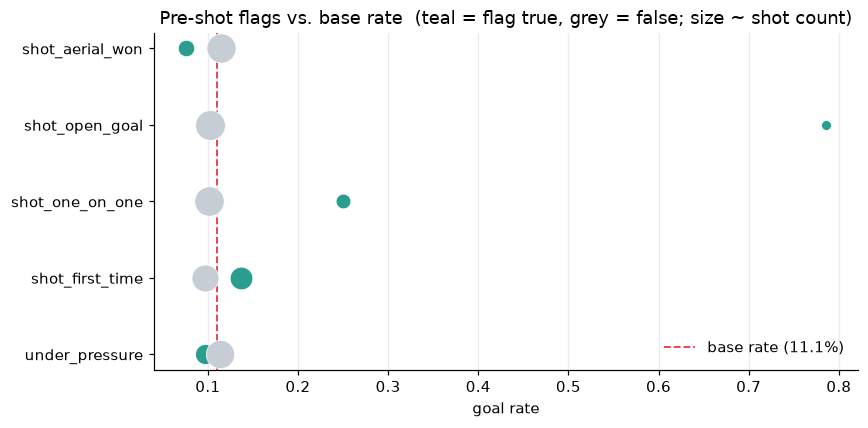

In [ ]:
base = shots["is_goal"].mean()
flags = ["under_pressure", "shot_first_time", "shot_one_on_one", "shot_open_goal", "shot_aerial_won"]

rows = []
for f in flags:
    for val in [True, False]:
        sub = shots[shots[f] == val]
        if len(sub) >= 30:
            rows.append({"flag": f, "value": val, "shots": len(sub), "rate": sub["is_goal"].mean()})

flag_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 4))
for i, f in enumerate(flags):
    sub = flag_df[flag_df["flag"] == f]
    for _, r in sub.iterrows():
        ax.scatter(r["rate"], i, s=np.sqrt(r["shots"]) * 4,
                   color="#2a9d8f" if r["value"] else "#c7cdd4",
                   zorder=3, edgecolors="white", linewidth=0.5)
ax.axvline(base, color="#e63946", linestyle="--", linewidth=1.2, label=f"base rate ({base:.1%})")
ax.set_yticks(range(len(flags)))
ax.set_yticklabels(flags)
ax.set_xlabel("goal rate")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Pre-shot flags vs. base rate  (teal = flag true, grey = false; size ~ shot count)")
fig.tight_layout()
fig.savefig(SAVE / "pre_shot_flags.png", bbox_inches="tight")
plt.show()

`shot_open_goal` and `shot_one_on_one` move conversion enormously — as they should; both describe a keeper who isn't in the way. They're rare (112 and 548 shots) but they're legitimately pre-shot: the player knows the goal is empty when they hit it.

`under_pressure` is the interesting one. It barely moves the base rate — but that's confounded, because pressure correlates with being close to goal, which raises conversion. A model with both features can separate what a raw crosstab cannot.

## 8. The benchmark to beat

StatsBomb ship their own xG on every shot. It's in the data, and it is **not** a feature — training on it would just teach our model to imitate theirs. It's the bar.

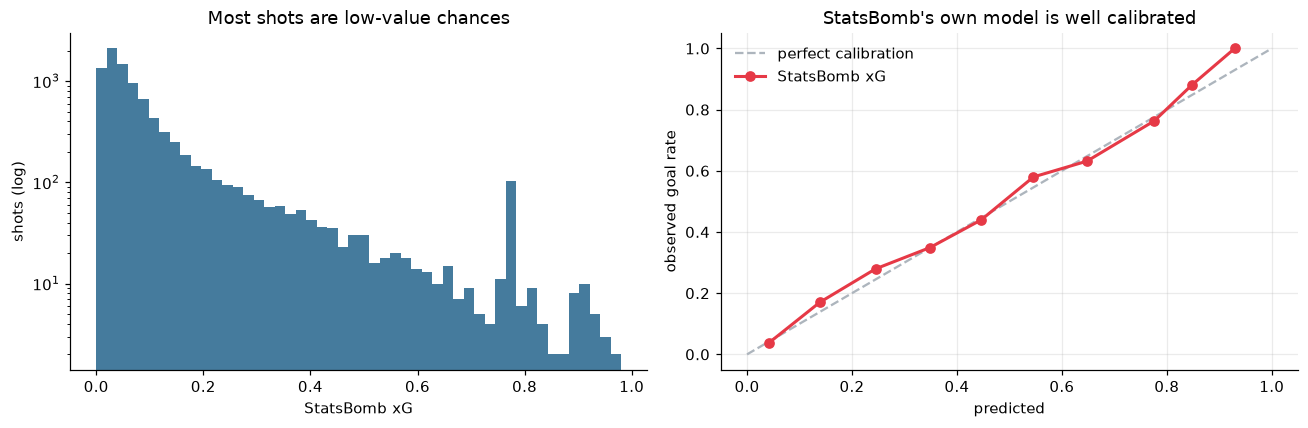

StatsBomb xG on this season   log loss 0.2593   Brier 0.0751
Predicting the base rate       log loss 0.3478   Brier 0.0984

total StatsBomb xG 980 vs 1014 actual goals — 0.966 ratio


In [ ]:
sb_xg = shots["shot_statsbomb_xg"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sb_xg, bins=50, color="#457b9d")
axes[0].set_yscale("log")
axes[0].set_xlabel("StatsBomb xG")
axes[0].set_ylabel("shots (log)")
axes[0].set_title("Most shots are low-value chances")
axes[0].spines[["top", "right"]].set_visible(False)

# Calibration: within each xG band, does the predicted rate match the observed one?
bands = pd.cut(sb_xg, np.linspace(0, 1, 11))
cal = shots.groupby(bands, observed=True).agg(predicted=("shot_statsbomb_xg", "mean"),
                                              observed=("is_goal", "mean"),
                                              n=("is_goal", "size"))
cal = cal[cal["n"] >= 20]
axes[1].plot([0, 1], [0, 1], "--", color="#adb5bd", label="perfect calibration")
axes[1].plot(cal["predicted"], cal["observed"], "o-", color="#e63946", linewidth=2, label="StatsBomb xG")
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("observed goal rate")
axes[1].set_title("StatsBomb's own model is well calibrated")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)
axes[1].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(SAVE / "statsbomb_xg_benchmark.png", bbox_inches="tight")
plt.show()

from sklearn.metrics import brier_score_loss, log_loss
print(f"StatsBomb xG on this season   log loss {log_loss(shots['is_goal'], sb_xg):.4f}"
      f"   Brier {brier_score_loss(shots['is_goal'], sb_xg):.4f}")
print(f"Predicting the base rate       log loss {log_loss(shots['is_goal'], np.full(len(shots), base)):.4f}"
      f"   Brier {brier_score_loss(shots['is_goal'], np.full(len(shots), base)):.4f}")
print(f"\ntotal StatsBomb xG {sb_xg.sum():.0f} vs {goals} actual goals — {sb_xg.sum()/goals:.3f} ratio")

Two things worth noting. StatsBomb's model is **well calibrated** on this season and its total xG lands within a couple of percent of actual goals scored — so it's a serious benchmark, not a strawman. And the base-rate comparison gives us the floor: any model that can't beat a constant 11% prediction has learned nothing at all.

Those two numbers bracket the problem. **Base rate is the floor, StatsBomb is the bar.**

## 9. Penalties

97 shots that need a decision.

In [ ]:
pens = shots[shots["is_penalty"]]
print(f"{len(pens)} penalties, {pens['is_goal'].mean():.1%} converted")
print(f"distinct locations: {pens['x'].round(0).astype(int).astype(str).str.cat(pens['y'].round(0).astype(int).astype(str), sep=',').nunique()}")
print(pens[["x", "y"]].describe().loc[["mean", "std", "min", "max"]].to_string())

97 penalties, 71.1% converted
distinct locations: 3
               x          y
mean  108.027835  40.039175
std     0.144872   0.097422
min   107.300000  39.400000
max   108.400000  40.300000


Every penalty is taken from the same spot, with no defenders, and converts at ~71%. There is no geometry to learn: the features that carry the whole model — distance, angle, defensive pressure — are *constant*. Including them would create a degenerate cluster the model memorises, which inflates the headline metric while teaching it nothing about open play.

**Decision: penalties are excluded from the xG model**, which is standard practice. They're flagged rather than dropped at ingestion (`is_penalty`), so the match-outcome model in step 5 can still count them — a penalty is still a goal on the scoreboard.

## 10. What this means for the feature layer

Carried into step 3:

| Finding | Consequence |
| --- | --- |
| Location dominates conversion | Distance and angle are the primary features; both are non-linear, favouring trees over logistic regression |
| Volume ≠ conversion | Shot count is a bad proxy for quality — the premise of the whole project |
| 11.1% goal rate | Score on log loss / Brier / calibration. Never accuracy |
| 81 shots lack a freeze frame | Defensive features need a defined fallback, not a silent NaN |
| Penalties are degenerate | Excluded from the xG model, retained for match outcome |
| StatsBomb xG is well calibrated | A real benchmark: base rate is the floor, StatsBomb is the bar |
| `play_pattern="Other"` is 89% penalties | Drops to 12 shots once penalties go — too sparse to encode; fold into a fallback category |
| Counters convert at 18.2%, corners at 8.9% | Play pattern is a real feature once the penalty artefact is removed |
| `under_pressure` looks flat | Confounded with distance — needs the model to disentangle, don't discard on the crosstab |

The freeze frames are the biggest unexploited asset: a full snapshot of player positions on 99.1% of shots, which is what makes "defenders in the shot cone" and true goalkeeper positioning computable. That's the interesting part of step 3.